# Реализация кода из статьи Google [How Important Is a Neuron?](https://arxiv.org/abs/1805.12233), перенесенная на детектор

In [1]:
import gc
import math

import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO
from torch.func import jvp

torch.set_grad_enabled(True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu")
DTYPE = torch.float32

print("device:", DEVICE)
print("torch:", torch.__version__)

device: mps
torch: 2.9.1


In [2]:
# Загрузка детектора
yolo = YOLO("yolo11s.pt")
model = yolo.model.to(DEVICE).eval()
class_names = yolo.names
num_classes_global = len(class_names)

print(type(model).__name__)
print("num classes:", len(class_names))
print("first 10 classes:", {k: class_names[k] for k in range(10)})

DetectionModel
num classes: 80
first 10 classes: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light'}


In [3]:
IMG_SIZE = 640
DEFAULT_LAYER_NAME = "prehead_all"

# Осмысленные "полные" слои / наборы слоёв для YOLO11s.
# Идея:
# - брать завершённые backbone stage,
# - fused-слои после Concat,
# - либо полный multi-scale pre-head срез перед Detect.
LAYER_GROUPS = {
    # Backbone stages
    "backbone_p2": ("model.2",),
    "backbone_p3": ("model.4",),
    "backbone_p4": ("model.6",),
    "backbone_p5": ("model.10",),

    # Neck fused layers (после слияния ветвей)
    "neck_td_p4_concat": ("model.12",),
    "neck_td_p4_out": ("model.13",),
    "neck_td_p3_concat": ("model.15",),
    "neck_td_p3_out": ("model.16",),
    "neck_bu_p4_concat": ("model.18",),
    "neck_bu_p4_out": ("model.19",),
    "neck_bu_p5_concat": ("model.21",),
    "neck_bu_p5_out": ("model.22",),

    # Pre-head single-scale outputs
    "prehead_p3": ("model.16",),
    "prehead_p4": ("model.19",),
    "prehead_p5": ("model.22",),

    # Главный кандидат: полный multi-scale слой перед Detect
    "prehead_all": ("model.16", "model.19", "model.22"),
}

def load_image(path, img_size=IMG_SIZE, pad_value=0.0):
    img = Image.open(path).convert("RGB")
    img_np = np.asarray(img).astype(np.uint8)

    h, w = img_np.shape[:2]
    if h == 0 or w == 0:
        raise ValueError(f"Некорректный размер изображения: {(h, w)}")

    scale = img_size / max(h, w)
    new_h = max(1, int(round(h * scale)))
    new_w = max(1, int(round(w * scale)))

    resized = np.asarray(
        Image.fromarray(img_np).resize((new_w, new_h), Image.Resampling.BICUBIC)
    ).astype(np.float32) / 255.0

    canvas = np.full((img_size, img_size, 3), pad_value, dtype=np.float32)
    top = (img_size - new_h) // 2
    left = (img_size - new_w) // 2
    canvas[top:top + new_h, left:left + new_w] = resized

    x = torch.from_numpy(canvas).permute(2, 0, 1).unsqueeze(0).to(DEVICE, DTYPE)
    meta = {
        "orig_hw": (h, w),
        "resized_hw": (new_h, new_w),
        "pad_top": top,
        "pad_left": left,
        "scale": scale,
        "img_size": img_size,
    }
    return x, canvas, meta

def black_baseline_like(x):
    return torch.zeros_like(x)

def clear_backend_cache():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    if hasattr(torch, "mps") and torch.mps.is_available():
        try:
            torch.mps.empty_cache()
        except Exception:
            pass

print("default layer:", DEFAULT_LAYER_NAME)
print("available named layer groups:")
for group_name, layers in LAYER_GROUPS.items():
    print(f"  {group_name:18s} -> {layers}")

default layer: prehead_all
available named layer groups:
  backbone_p2        -> ('model.2',)
  backbone_p3        -> ('model.4',)
  backbone_p4        -> ('model.6',)
  backbone_p5        -> ('model.10',)
  neck_td_p4_concat  -> ('model.12',)
  neck_td_p4_out     -> ('model.13',)
  neck_td_p3_concat  -> ('model.15',)
  neck_td_p3_out     -> ('model.16',)
  neck_bu_p4_concat  -> ('model.18',)
  neck_bu_p4_out     -> ('model.19',)
  neck_bu_p5_concat  -> ('model.21',)
  neck_bu_p5_out     -> ('model.22',)
  prehead_p3         -> ('model.16',)
  prehead_p4         -> ('model.19',)
  prehead_p5         -> ('model.22',)
  prehead_all        -> ('model.16', 'model.19', 'model.22')


In [4]:
def print_main_yolo_layers(model, sample_input, max_depth=2):
    """
    Печатает основные слои YOLO и shape их выходов на одном forward-pass.
    - depth=1: model.0, model.1, ...
    - depth=2: model.15.cv1, model.15.cv2, ...
    """
    module_outputs = {}
    handles = []

    def make_hook(name):
        def hook(module, inp, out):
            module_outputs[name] = out
        return hook

    try:
        for name, module in model.named_modules():
            if name == "":
                continue
            if not name.startswith("model."):
                continue

            depth = name.count(".")
            if depth <= max_depth:
                handles.append(module.register_forward_hook(make_hook(name)))

        with torch.no_grad():
            _ = model(sample_input)

        print("Main YOLO layers:\n")
        for name, module in model.named_modules():
            if name == "":
                continue
            if not name.startswith("model."):
                continue

            depth = name.count(".")
            if depth <= max_depth:
                out = module_outputs.get(name, None)
                if torch.is_tensor(out):
                    shape_str = str(tuple(out.shape))
                elif isinstance(out, (list, tuple)):
                    tensor_shapes = [tuple(x.shape) for x in out if torch.is_tensor(x)]
                    shape_str = str(tensor_shapes) if tensor_shapes else f"<{type(out).__name__}>"
                elif out is None:
                    shape_str = "<no output captured>"
                else:
                    shape_str = f"<{type(out).__name__}>"

                print(f"{name:25s} {type(module).__name__:12s} output={shape_str}")
    finally:
        for h in handles:
            h.remove()


sample_x, _, _ = load_image("data/person.png")
print_main_yolo_layers(model, sample_x, max_depth=1)

Main YOLO layers:

model.0                   Conv         output=(1, 32, 320, 320)
model.1                   Conv         output=(1, 64, 160, 160)
model.2                   C3k2         output=(1, 128, 160, 160)
model.3                   Conv         output=(1, 128, 80, 80)
model.4                   C3k2         output=(1, 256, 80, 80)
model.5                   Conv         output=(1, 256, 40, 40)
model.6                   C3k2         output=(1, 256, 40, 40)
model.7                   Conv         output=(1, 512, 20, 20)
model.8                   C3k2         output=(1, 512, 20, 20)
model.9                   SPPF         output=(1, 512, 20, 20)
model.10                  C2PSA        output=(1, 512, 20, 20)
model.11                  Upsample     output=(1, 512, 40, 40)
model.12                  Concat       output=(1, 768, 40, 40)
model.13                  C3k2         output=(1, 256, 40, 40)
model.14                  Upsample     output=(1, 256, 80, 80)
model.15                  Concat

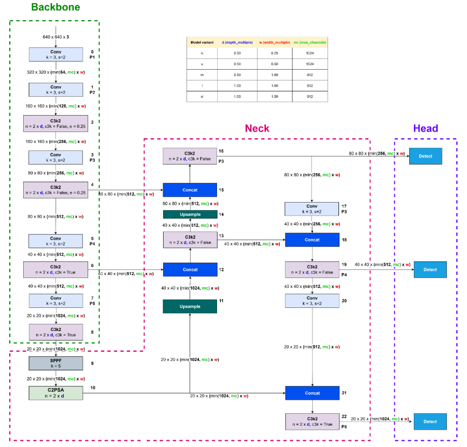

In [5]:
# Вспомогательные функции для hooks и plotting

class LayerHook:
    def __init__(self, model, layer_name_or_names):
        self.layer_names = self._normalize_layer_names(layer_name_or_names)
        self.layer_store = {}
        self.handles = []
        modules = dict(model.named_modules())

        for layer_name in self.layer_names:
            if layer_name not in modules:
                raise KeyError(f"Слой '{layer_name}' не найден в model.named_modules()")
            self.handles.append(modules[layer_name].register_forward_hook(self._make_hook(layer_name)))

    @staticmethod
    def _normalize_layer_names(layer_name_or_names):
        if isinstance(layer_name_or_names, str):
            return (layer_name_or_names,)
        if isinstance(layer_name_or_names, (list, tuple)):
            return tuple(layer_name_or_names)
        raise TypeError(
            f"layer_name_or_names должен быть str/list/tuple, получено {type(layer_name_or_names).__name__}"
        )

    def _make_hook(self, layer_name):
        def hook(module, inp, out):
            self.layer_store[layer_name] = out
        return hook

    def clear(self):
        self.layer_store.clear()

    def get(self):
        if len(self.layer_names) == 1:
            return self.layer_store[self.layer_names[0]]
        return tuple(self.layer_store[name] for name in self.layer_names)

    def remove(self):
        for h in self.handles:
            h.remove()


def unwrap_tensor(output):
    if torch.is_tensor(output):
        return output
    if isinstance(output, (list, tuple)):
        tensor_items = []
        for item in output:
            if torch.is_tensor(item):
                tensor_items.append(item)
            elif isinstance(item, (list, tuple)):
                for sub_item in item:
                    if torch.is_tensor(sub_item):
                        tensor_items.append(sub_item)
        if len(tensor_items) == 1:
            return tensor_items[0]
        if len(tensor_items) > 1:
            return tuple(tensor_items)
    raise TypeError(f"Не удалось извлечь tensor activation из output типа {type(output).__name__}")


def reduce_filter_scores(cond_tensor):
    if torch.is_tensor(cond_tensor):
        tensors = (cond_tensor,)
    elif isinstance(cond_tensor, (list, tuple)):
        tensors = tuple(cond_tensor)
    else:
        raise TypeError(f"cond_tensor должен быть tensor/list/tuple, получено {type(cond_tensor).__name__}")

    reduced_parts = []
    for part in tensors:
        if part.ndim < 2:
            raise ValueError(
                f"Ожидался tensor с batch-осью и хотя бы одной feature-осью, получено shape={tuple(part.shape)}"
            )

        per_sample = part[0]
        if per_sample.ndim == 1:
            reduced_parts.append(per_sample)
        else:
            reduce_dims = tuple(range(1, per_sample.ndim))
            reduced_parts.append(per_sample.sum(dim=reduce_dims))

    if len(reduced_parts) == 1:
        return reduced_parts[0]
    return torch.cat(reduced_parts, dim=0)


def layer_shape_repr(act):
    if torch.is_tensor(act):
        return tuple(act.shape)
    if isinstance(act, (list, tuple)):
        return tuple(tuple(x.shape) for x in act if torch.is_tensor(x))
    return f"<{type(act).__name__}>"


def sum_conductance_tensor(cond_tensor):
    if torch.is_tensor(cond_tensor):
        return cond_tensor.sum()
    if isinstance(cond_tensor, (list, tuple)):
        total = None
        for part in cond_tensor:
            part_sum = part.sum()
            total = part_sum if total is None else (total + part_sum)
        return total
    raise TypeError(f"cond_tensor должен быть tensor/list/tuple, получено {type(cond_tensor).__name__}")


def _normalize_map(arr):
    arr = arr.astype(np.float32)
    arr = arr - arr.min()
    denom = arr.max()
    if denom > 0:
        arr = arr / denom
    return arr


def _resize_map_nearest(arr, out_hw):
    h_out, w_out = out_hw
    h_in, w_in = arr.shape

    row_idx = np.floor(np.arange(h_out) * (h_in / h_out)).astype(int)
    col_idx = np.floor(np.arange(w_out) * (w_in / w_out)).astype(int)

    row_idx = np.clip(row_idx, 0, h_in - 1)
    col_idx = np.clip(col_idx, 0, w_in - 1)
    return arr[row_idx][:, col_idx]


def plot_total_conductance_overlay(image_np, cond_tensor, title=None):
    if torch.is_tensor(cond_tensor):
        parts = [cond_tensor]
    elif isinstance(cond_tensor, (list, tuple)):
        parts = list(cond_tensor)
    else:
        raise TypeError(f"cond_tensor должен быть tensor/list/tuple, получено {type(cond_tensor).__name__}")

    spatial_parts = []
    for part in parts:
        cond_np = part[0].detach().cpu().numpy()
        if cond_np.ndim >= 3:
            spatial_parts.append(np.abs(cond_np).sum(axis=0))

    if not spatial_parts:
        print("Общий spatial plot пропущен: у выбранного слоя/набора нет пространственных осей.")
        return

    total_map = spatial_parts[0]
    for extra_map in spatial_parts[1:]:
        if extra_map.shape != total_map.shape:
            extra_map = _resize_map_nearest(extra_map, total_map.shape)
        total_map = total_map + extra_map

    total_map = _normalize_map(total_map)
    total_map = _resize_map_nearest(total_map, image_np.shape[:2])

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(image_np, interpolation="nearest")
    heat = ax.imshow(total_map, cmap="jet", alpha=0.45, interpolation="nearest")
    ax.axis("off")
    ax.set_title(title or "Total conductance overlay")

    cbar = fig.colorbar(heat, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Normalized |conductance|", rotation=90)
    plt.show()


def plot_top_filter_overlays(image_np, cond_tensor, filter_scores, top_idx, top_n=5):
    if torch.is_tensor(cond_tensor):
        parts = [cond_tensor]
    elif isinstance(cond_tensor, (list, tuple)):
        parts = list(cond_tensor)
    else:
        raise TypeError(f"cond_tensor должен быть tensor/list/tuple, получено {type(cond_tensor).__name__}")

    spatial_parts = []
    offset = 0
    for part in parts:
        cond_np = part[0].detach().cpu().numpy()
        channels = cond_np.shape[0]
        if cond_np.ndim >= 3:
            spatial_parts.append((offset, offset + channels, cond_np))
        offset += channels

    if not spatial_parts:
        print("Spatial overlays для отдельных фильтров пропущены: у выбранного слоя/набора нет пространственных осей.")
        return

    if top_n == -1:
        selected_idx = top_idx.tolist()
    else:
        top_n = min(top_n, len(top_idx))
        selected_idx = top_idx[:top_n].tolist()

    for rank, idx in enumerate(selected_idx, start=1):
        chosen_map = None
        for start, end, cond_np in spatial_parts:
            if start <= idx < end:
                local_idx = idx - start
                chosen_map = np.abs(cond_np[local_idx])
                break

        if chosen_map is None:
            continue

        fmap = _normalize_map(chosen_map)
        fmap = _resize_map_nearest(fmap, image_np.shape[:2])

        plt.figure(figsize=(6, 6))
        plt.imshow(image_np, interpolation="nearest")
        plt.imshow(fmap, cmap="jet", alpha=0.45, interpolation="nearest")
        plt.axis("off")
        plt.title(f"Filter {idx} conductance = {float(filter_scores[idx]):+.6f} (rank {rank})")
        plt.show()

In [6]:
# %%
def _collect_tensors(obj):
    tensors = []

    def _collect(x):
        if torch.is_tensor(x):
            tensors.append(x)
        elif isinstance(x, dict):
            for v in x.values():
                _collect(v)
        elif isinstance(x, (list, tuple)):
            for v in x:
                _collect(v)

    _collect(obj)
    return tensors


def unpack_detector_output(raw_output):
    """
    Явно разбирает output Ultralytics YOLO detector.

    Ожидаемые варианты:
    - tensor y
    - (y, preds)

    где:
    - y: основной dense prediction tensor головы детектора
    - preds: дополнительные сырые/промежуточные данные головы

    Мы больше НЕ выбираем "самый большой tensor", потому что это легко приводит
    к выбору feature map вместо detector output.
    """
    if torch.is_tensor(raw_output):
        return raw_output, None

    if isinstance(raw_output, (list, tuple)):
        if len(raw_output) == 0:
            raise RuntimeError("Пустой output у detector.")

        y = raw_output[0] if torch.is_tensor(raw_output[0]) else None
        preds = raw_output[1] if len(raw_output) > 1 else None

        if y is None:
            first_tensor = None
            for item in raw_output:
                if torch.is_tensor(item):
                    first_tensor = item
                    break
            if first_tensor is None:
                raise RuntimeError("Не удалось найти основной detector output tensor в tuple/list output.")
            y = first_tensor

        return y, preds

    raise RuntimeError(f"Неожиданный тип detector output: {type(raw_output).__name__}")


# %%
def normalize_detection_y(y, num_classes):
    """
    Приводит основной detector output к форме [B, Q, D].

    Поддерживаем:
    - [B, Q, D]
    - [B, D, Q]
    - [B, D, H, W] -> [B, H*W, D]
    - [B, H, W, D] -> [B, H*W, D]

    Важно: для inference output YOLO вида (1, 84, 8400)
    это формат [B, D, Q], а НЕ [B, Q, D].
    Раньше код ошибочно оставлял его как есть, и тогда:
    - первые 4 QUERY интерпретировались как box coords,
    - последние 80 QUERY интерпретировались как class logits.
    Именно это ломало target selection и bbox.
    """
    shape = tuple(y.shape)
    d_min = 4 + num_classes

    if y.ndim == 3:
        b, a, c = y.shape

        # Случай [B, D, Q], типичный для YOLO inference output, например (1, 84, 8400)
        # Здесь axis=1 -- channel dim (4 + num_classes), axis=2 -- число queries.
        if a == d_min and c != d_min:
            return y.transpose(1, 2)

        # Случай [B, Q, D]
        if c == d_min and a != d_min:
            return y

        # Более общий fallback:
        # если только одна из осей {1,2} похожа на channel dim, используем её как D.
        if a >= d_min and c < d_min:
            return y.transpose(1, 2)
        if c >= d_min and a < d_min:
            return y

        # Если обе оси >= d_min, выбираем меньшую как D, потому что
        # channel dim обычно 4+num_classes, а query dim обычно сильно больше.
        if a >= d_min and c >= d_min:
            if a <= c:
                return y.transpose(1, 2)
            return y

        raise RuntimeError(f"Не удалось интерпретировать 3D detector output shape={shape}")

    if y.ndim == 4:
        # [B, D, H, W]
        if y.shape[1] >= d_min:
            b, d, h, w = y.shape
            return y.permute(0, 2, 3, 1).reshape(b, h * w, d)

        # [B, H, W, D]
        if y.shape[-1] >= d_min:
            b, h, w, d = y.shape
            return y.reshape(b, h * w, d)

        raise RuntimeError(f"Не удалось интерпретировать 4D detector output shape={shape}")

    raise RuntimeError(f"Ожидался 3D или 4D detector output, получено shape={shape}")


# %%
def parse_detection_head(raw_output, num_classes):
    """
    Возвращает нормализованное dense detector prediction из ОСНОВНОГО выхода головы,
    а не из случайного tensor-а внутри tuple/dict.
    """
    y, preds = unpack_detector_output(raw_output)
    y_shape = tuple(y.shape)
    pred = normalize_detection_y(y, num_classes=num_classes)
    pred_shape = tuple(pred.shape)

    if pred.shape[-1] < 4 + num_classes:
        raise RuntimeError(
            f"Последняя размерность слишком мала: ожидалось >= {4 + num_classes}, получено {pred.shape[-1]}"
        )

    boxes = pred[..., :4]                  # [B, Q, 4]
    cls_logits = pred[..., -num_classes:]  # [B, Q, C]

    return {
        "y": y,
        "y_shape": y_shape,
        "pred": pred,
        "pred_shape": pred_shape,
        "boxes": boxes,
        "cls_logits": cls_logits,
        "preds": preds,
    }

In [7]:
# %%
# Выбор target на конечном изображении.
#
# Мы фиксируем target по x = исходной картинке,
# а потом используем тот же target на всех x(α).

# %%
def pick_fixed_query_target(raw_output, num_classes):
    parsed = parse_detection_head(raw_output, num_classes=num_classes)
    cls_logits = parsed["cls_logits"][0]  # [Q, C]

    flat_idx = int(cls_logits.reshape(-1).argmax().item())
    q_idx = flat_idx // num_classes
    class_idx = flat_idx % num_classes
    score = float(cls_logits[q_idx, class_idx].item())

    return {
        "mode": "fixed_query",
        "query_index": q_idx,
        "class_index": class_idx,
        "score": score,
        "box_xywh": parsed["boxes"][0, q_idx].detach().cpu(),
        "y_shape": parsed["y_shape"],
        "pred_shape": parsed["pred_shape"],
    }


def xywh_to_xyxy(xywh):
    x, y, w, h = xywh
    x1 = x - w / 2.0
    y1 = y - h / 2.0
    x2 = x + w / 2.0
    y2 = y + h / 2.0
    return np.array([x1, y1, x2, y2], dtype=np.float32)


def make_roi_mask_from_fixed_box(boxes_xywh, fixed_box_xywh, center_only=True):
    boxes = boxes_xywh.detach().cpu().numpy()
    fixed_xyxy = xywh_to_xyxy(np.asarray(fixed_box_xywh))

    if center_only:
        cx = boxes[:, 0]
        cy = boxes[:, 1]
        mask = (
            (cx >= fixed_xyxy[0]) &
            (cx <= fixed_xyxy[2]) &
            (cy >= fixed_xyxy[1]) &
            (cy <= fixed_xyxy[3])
        )
    else:
        cx = boxes[:, 0]
        cy = boxes[:, 1]
        mask = (
            (cx >= fixed_xyxy[0]) &
            (cx <= fixed_xyxy[2]) &
            (cy >= fixed_xyxy[1]) &
            (cy <= fixed_xyxy[3])
        )

    return torch.from_numpy(mask)


# %%
# Выбор target на конечном изображении.
#
# Мы фиксируем target по x = исходной картинке,
# а потом используем тот же target на всех x(α).

def pick_fixed_query_target(raw_output, num_classes):
    parsed = parse_detection_head(raw_output, num_classes=num_classes)
    cls_logits = parsed["cls_logits"][0]  # [Q, C]

    flat_idx = int(cls_logits.reshape(-1).argmax().item())
    q_idx = flat_idx // num_classes
    class_idx = flat_idx % num_classes
    score = float(cls_logits[q_idx, class_idx].item())

    return {
        "mode": "fixed_query",
        "query_index": q_idx,
        "class_index": class_idx,
        "score": score,
        "box_xywh": parsed["boxes"][0, q_idx].detach().cpu(),
        "y_shape": parsed["y_shape"],
        "pred_shape": parsed["pred_shape"],
    }


def xywh_to_xyxy(xywh):
    x, y, w, h = xywh
    x1 = x - w / 2.0
    y1 = y - h / 2.0
    x2 = x + w / 2.0
    y2 = y + h / 2.0
    return np.array([x1, y1, x2, y2], dtype=np.float32)


def make_roi_mask_from_fixed_box(boxes_xywh, fixed_box_xywh, center_only=True):
    boxes = boxes_xywh.detach().cpu().numpy()
    fixed_xyxy = xywh_to_xyxy(np.asarray(fixed_box_xywh))

    if center_only:
        cx = boxes[:, 0]
        cy = boxes[:, 1]
        mask = (
            (cx >= fixed_xyxy[0]) &
            (cx <= fixed_xyxy[2]) &
            (cy >= fixed_xyxy[1]) &
            (cy <= fixed_xyxy[3])
        )
    else:
        cx = boxes[:, 0]
        cy = boxes[:, 1]
        mask = (
            (cx >= fixed_xyxy[0]) &
            (cx <= fixed_xyxy[2]) &
            (cy >= fixed_xyxy[1]) &
            (cy <= fixed_xyxy[3])
        )

    return torch.from_numpy(mask)


# %%
def pick_fixed_roi_target(raw_output, num_classes, min_queries=1, roi_mode="fixed_roi_lse", roi_top_k=-1):
    if roi_mode not in {"fixed_roi_lse", "fixed_roi_logmeanexp", "fixed_roi_mean"}:
        raise ValueError(f"Неизвестный roi_mode: {roi_mode}")
    if roi_top_k == 0 or roi_top_k < -1:
        raise ValueError(f"roi_top_k должен быть -1 или положительным целым, получено {roi_top_k}")

    parsed = parse_detection_head(raw_output, num_classes=num_classes)
    cls_logits = parsed["cls_logits"][0]   # [Q, C]
    boxes = parsed["boxes"][0]             # [Q, 4]

    flat_idx = int(cls_logits.reshape(-1).argmax().item())
    best_q = flat_idx // num_classes
    class_idx = flat_idx % num_classes

    fixed_box = boxes[best_q].detach().cpu().numpy()
    roi_mask = make_roi_mask_from_fixed_box(boxes, fixed_box, center_only=True)

    if roi_mask.sum().item() < min_queries:
        roi_mask[best_q] = True

    roi_indices = torch.nonzero(roi_mask, as_tuple=False).flatten()
    roi_scores = cls_logits[roi_indices, class_idx]

    if roi_top_k != -1 and roi_indices.numel() > roi_top_k:
        top_local = torch.topk(roi_scores, k=roi_top_k).indices
        top_local = top_local.to(roi_indices.device)
        roi_indices = roi_indices[top_local]
        new_roi_mask = torch.zeros_like(roi_mask, dtype=torch.bool)
        new_roi_mask[roi_indices] = True
        roi_mask = new_roi_mask
        roi_scores = cls_logits[roi_indices, class_idx]

    selected = roi_scores
    if roi_mode == "fixed_roi_lse":
        pooled_score = float(torch.logsumexp(selected, dim=0).item())
    elif roi_mode == "fixed_roi_logmeanexp":
        pooled_score = float((torch.logsumexp(selected, dim=0) - math.log(float(selected.numel()))).item())
    else:
        pooled_score = float(selected.mean().item())

    return {
        "mode": roi_mode,
        "class_index": class_idx,
        "seed_query_index": best_q,
        "fixed_box_xywh": torch.tensor(fixed_box),
        "roi_mask": roi_mask.clone(),
        "roi_indices": roi_indices.detach().cpu(),
        "roi_top_k": roi_top_k,
        "score": pooled_score,
        "y_shape": parsed["y_shape"],
        "pred_shape": parsed["pred_shape"],
    }

In [8]:
# %%
# Scalar target F(x) для разных режимов
#
# fixed_query:
#   F(x) = s[q*, c]
#
# fixed_roi_lse:
#   F(x) = logsumexp({s[q, c] : q in ROI*})
#
# fixed_roi_logmeanexp:
#   F(x) = logsumexp({s[q, c] : q in ROI*}) - log(|ROI*|)
#
# fixed_roi_mean:
#   F(x) = mean({s[q, c] : q in ROI*})
#
# Важно: logmeanexp и mean обычно дают более стабильную baseline-нормировку,
# чем чистый logsumexp по большому ROI.

def detection_scalar_target(raw_output, target_spec, num_classes):
    parsed = parse_detection_head(raw_output, num_classes=num_classes)
    cls_logits = parsed["cls_logits"][0]  # [Q, C]

    if target_spec["mode"] == "fixed_query":
        q = target_spec["query_index"]
        c = target_spec["class_index"]
        return cls_logits[q, c]

    if target_spec["mode"] in {"fixed_roi_lse", "fixed_roi_logmeanexp", "fixed_roi_mean"}:
        c = target_spec["class_index"]
        roi_mask = target_spec["roi_mask"].to(cls_logits.device)
        selected = cls_logits[roi_mask, c]

        if target_spec["mode"] == "fixed_roi_lse":
            return torch.logsumexp(selected, dim=0)

        if target_spec["mode"] == "fixed_roi_logmeanexp":
            return torch.logsumexp(selected, dim=0) - math.log(float(selected.numel()))

        if target_spec["mode"] == "fixed_roi_mean":
            return selected.mean()

    raise ValueError(f"Неизвестный mode: {target_spec['mode']}")

In [9]:
# %%
def compute_detector_conductance(
    model,
    hook,
    x,
    x0,
    target_spec,
    num_classes,
    n_steps=64,
    fd_eps=1e-3,
    clear_every=8,
):
    x = x.contiguous()
    x0 = x0.contiguous()
    delta_x = (x - x0).contiguous()

    def forward_with_layer(x_in):
        hook.clear()
        out = model(x_in)
        act = unwrap_tensor(hook.get())
        return out, act

    def to_part_tuple(obj):
        if torch.is_tensor(obj):
            return (obj,)
        if isinstance(obj, (list, tuple)):
            tensors = tuple(x for x in obj if torch.is_tensor(x))
            if not tensors:
                raise TypeError("Не удалось извлечь tensor parts из composite activation")
            return tensors
        raise TypeError(f"Ожидался tensor/list/tuple, получено {type(obj).__name__}")

    alphas = torch.linspace(0.0, 1.0, n_steps + 1, device=x.device, dtype=x.dtype)
    step = 1.0 / n_steps

    cond_accum_parts = None
    used_fallback = False

    for k in range(n_steps):
        alpha = (alphas[k] + alphas[k + 1]) / 2.0
        x_alpha = (x0 + alpha * delta_x).contiguous().detach().requires_grad_(True)

        raw_out, act = forward_with_layer(x_alpha)
        score = detection_scalar_target(raw_out, target_spec=target_spec, num_classes=num_classes)

        act_parts = to_part_tuple(act)
        grad_parts = torch.autograd.grad(
            score, act_parts, retain_graph=False, create_graph=False, allow_unused=True
        )
        grad_parts = tuple(torch.zeros_like(a) if g is None else g for a, g in zip(act_parts, grad_parts))

        try:
            raise RuntimeError("view size is not compatible with input tensor's size and stride")
            def act_only(inp):
                inp = inp.contiguous()
                _, a = forward_with_layer(inp)
                return to_part_tuple(a)

            _, act_tangent_parts = jvp(act_only, (x_alpha,), (delta_x,))
            act_tangent_parts = to_part_tuple(act_tangent_parts)

        except RuntimeError as e:
            if "view size is not compatible with input tensor's size and stride" not in str(e):
                raise

            used_fallback = True

            alpha_plus = min(float(alpha.item()) + fd_eps, 1.0)
            alpha_minus = max(float(alpha.item()) - fd_eps, 0.0)
            denom = alpha_plus - alpha_minus

            if denom == 0.0:
                raise RuntimeError("Не удалось построить finite-difference fallback для dy/dalpha.")

            with torch.no_grad():
                _, act_plus = forward_with_layer((x0 + alpha_plus * delta_x).contiguous())
                _, act_minus = forward_with_layer((x0 + alpha_minus * delta_x).contiguous())

            act_plus_parts = to_part_tuple(act_plus)
            act_minus_parts = to_part_tuple(act_minus)
            act_tangent_parts = tuple((ap - am) / denom for ap, am in zip(act_plus_parts, act_minus_parts))
            del act_plus, act_minus, act_plus_parts, act_minus_parts

        integrand_parts = tuple(g * t for g, t in zip(grad_parts, act_tangent_parts))

        if cond_accum_parts is None:
            cond_accum_parts = tuple(part.detach() for part in integrand_parts)
        else:
            cond_accum_parts = tuple(acc + part.detach() for acc, part in zip(cond_accum_parts, integrand_parts))

        del x_alpha, raw_out, act, score, act_parts, grad_parts, act_tangent_parts, integrand_parts
        hook.clear()

        if (k + 1) % clear_every == 0:
            clear_backend_cache()

    cond_parts = tuple(part * step for part in cond_accum_parts)
    clear_backend_cache()

    if used_fallback:
        print("Предупреждение: jvp на текущем backend не сработал, для dy/dalpha использована конечная разность.")

    if len(cond_parts) == 1:
        return cond_parts[0]
    return cond_parts

In [10]:
# %%
# Полезная визуализация target box/ROI на картинке

def draw_box_on_image(image_np, box_xywh, title=None):
    img = image_np.copy()
    h, w = img.shape[:2]

    x, y, bw, bh = [float(v) for v in box_xywh]
    x1 = int(round(x - bw / 2))
    y1 = int(round(y - bh / 2))
    x2 = int(round(x + bw / 2))
    y2 = int(round(y + bh / 2))

    x1 = max(0, min(w - 1, x1))
    y1 = max(0, min(h - 1, y1))
    x2 = max(0, min(w - 1, x2))
    y2 = max(0, min(h - 1, y2))

    plt.figure(figsize=(6, 6))
    plt.imshow(img, interpolation="nearest")
    plt.gca().add_patch(
        plt.Rectangle((x1, y1), max(1, x2 - x1), max(1, y2 - y1), fill=False, linewidth=2, edgecolor="lime")
    )
    plt.axis("off")
    plt.title(title or "Target box")
    plt.show()

In [11]:
# %%
def run_detector_conductance(
    image_path,
    mode="fixed_query",
    layer_name=DEFAULT_LAYER_NAME,
    n_steps=64,
    top_n=5,
    roi_top_k=-1,
    fd_eps=1e-3,
    clear_every=8,
):
    if mode not in {"fixed_query", "fixed_roi_lse", "fixed_roi_logmeanexp", "fixed_roi_mean"}:
        raise ValueError(f"Неизвестный mode: {mode}")

    if layer_name in LAYER_GROUPS:
        resolved_layer_names = LAYER_GROUPS[layer_name]
        resolved_layer_label = f"{layer_name} -> {resolved_layer_names}"
    else:
        resolved_layer_names = (layer_name,)
        resolved_layer_label = str(resolved_layer_names)

    x, img_np, meta = load_image(image_path)
    x0 = black_baseline_like(x)

    hook = LayerHook(model, resolved_layer_names)

    try:
        def forward_with_layer(x_in):
            hook.clear()
            out = model(x_in)
            act = unwrap_tensor(hook.get())
            return out, act

        with torch.no_grad():
            raw_out, act = forward_with_layer(x)
            parsed_x = parse_detection_head(raw_out, num_classes=len(class_names))

            if mode == "fixed_query":
                target_spec = pick_fixed_query_target(raw_out, num_classes=len(class_names))

                q = target_spec["query_index"]
                c = target_spec["class_index"]
                target_class_name = class_names[c]
                target_score = target_spec["score"]
                target_box = target_spec["box_xywh"].numpy()

                extra_lines = [
                    ("mode", "fixed_query"),
                    ("target query index", q),
                    ("target class", f"{c} {target_class_name}"),
                    ("target raw score at x", target_score),
                    ("detector y shape", target_spec["y_shape"]),
                    ("normalized pred shape", target_spec["pred_shape"]),
                ]

            else:
                target_spec = pick_fixed_roi_target(
                    raw_out,
                    num_classes=len(class_names),
                    roi_mode=mode,
                    roi_top_k=roi_top_k,
                )

                c = target_spec["class_index"]
                target_class_name = class_names[c]
                seed_q = target_spec["seed_query_index"]
                target_box = target_spec["fixed_box_xywh"].numpy()
                roi_count = int(target_spec["roi_mask"].sum().item())
                target_score = target_spec["score"]

                extra_lines = [
                    ("mode", mode),
                    ("seed query index", seed_q),
                    ("target class", f"{c} {target_class_name}"),
                    ("ROI query count", roi_count),
                    ("roi_top_k", target_spec["roi_top_k"]),
                    ("target pooled score at x", target_score),
                    ("detector y shape", target_spec["y_shape"]),
                    ("normalized pred shape", target_spec["pred_shape"]),
                ]

        cond_tensor = compute_detector_conductance(
            model=model,
            hook=hook,
            x=x,
            x0=x0,
            target_spec=target_spec,
            num_classes=len(class_names),
            n_steps=n_steps,
            fd_eps=fd_eps,
            clear_every=clear_every,
        )

        filter_scores = reduce_filter_scores(cond_tensor)
        layer_score = sum_conductance_tensor(cond_tensor)

        if top_n == -1:
            topk = filter_scores.numel()
        else:
            topk = min(10, filter_scores.numel())

        top_vals, top_idx = torch.topk(filter_scores.abs(), k=topk)

        with torch.no_grad():
            raw_x, _ = forward_with_layer(x)
            raw_x0, _ = forward_with_layer(x0)
            fx = float(detection_scalar_target(raw_x, target_spec, len(class_names)).item())
            fx0 = float(detection_scalar_target(raw_x0, target_spec, len(class_names)).item())
            abs_error = abs((fx - fx0) - float(layer_score.item()))

        print("image:", image_path)
        print("layer request:", layer_name)
        print("resolved layer set:", resolved_layer_label)
        for key, value in extra_lines:
            print(f"{key}: {value}")
        print("layer activation shape:", layer_shape_repr(act))
        print("cond tensor shape:", layer_shape_repr(cond_tensor))
        print("filter_scores shape:", tuple(filter_scores.shape))

        print("\ntop filters by |conductance|:")
        preview_n = filter_scores.numel() if top_n == -1 else min(10, len(top_idx))
        for rank, idx in enumerate(top_idx[:preview_n].tolist(), start=1):
            val = float(filter_scores[idx].item())
            print(f"{rank:2d}. filter {idx:4d}: {val:+.6f}")

        print("\nlayer conductance sum:", float(layer_score.item()))
        print("F(x)            =", fx)
        print("F(x0)           =", fx0)
        print("F(x) - F(x0)    =", fx - fx0)
        print("sum conductance =", float(layer_score.item()))
        print("abs error       =", abs_error)

        box_title = (
            f"Fixed-query target box, class={target_class_name}"
            if mode == "fixed_query"
            else f"Fixed ROI seed box, class={target_class_name}"
        )
        overlay_title = f"Total conductance, layer={layer_name}, mode={mode}, class={target_class_name}"

        draw_box_on_image(img_np, target_box, title=box_title)

        with torch.no_grad():
            cls_logits_x = parsed_x["cls_logits"][0]
            topk_flat = torch.topk(cls_logits_x.reshape(-1), k=min(10, cls_logits_x.numel()))
            print("\nTop raw detector queries by class score:")
            for rank, flat_idx in enumerate(topk_flat.indices.tolist(), start=1):
                q_idx = flat_idx // len(class_names)
                c_idx = flat_idx % len(class_names)
                score = float(cls_logits_x[q_idx, c_idx].item())
                box = parsed_x["boxes"][0, q_idx].detach().cpu().numpy()
                print(f"{rank:2d}. query={q_idx:4d} class={c_idx:3d} ({class_names[c_idx]}) score={score:+.6f} box_xywh={box}")

            if mode != "fixed_query":
                roi_indices = target_spec["roi_indices"]
                print("\nSelected ROI queries:")
                for rank, q_idx in enumerate(roi_indices.tolist(), start=1):
                    score = float(cls_logits_x[q_idx, target_spec["class_index"]].item())
                    box = parsed_x["boxes"][0, q_idx].detach().cpu().numpy()
                    print(f"{rank:2d}. query={q_idx:4d} class={target_spec['class_index']:3d} ({target_class_name}) score={score:+.6f} box_xywh={box}")

        plot_total_conductance_overlay(img_np, cond_tensor, title=overlay_title)
        plot_top_filter_overlays(img_np, cond_tensor, filter_scores, top_idx, top_n=top_n)

        return {
            "mode": mode,
            "image_path": image_path,
            "layer_name": layer_name,
            "resolved_layer_names": resolved_layer_names,
            "target_spec": target_spec,
            "cond_tensor": cond_tensor,
            "filter_scores": filter_scores,
            "layer_score": layer_score,
            "top_idx": top_idx,
            "top_vals": top_vals,
            "fx": fx,
            "fx0": fx0,
            "abs_error": abs_error,
        }

    finally:
        hook.remove()
        clear_backend_cache()

Предупреждение: jvp на текущем backend не сработал, для dy/dalpha использована конечная разность.
image: data/person.png
layer request: model.22
resolved layer set: ('model.22',)
mode: fixed_roi_mean
seed query index: 8248
target class: 0 person
ROI query count: 5
roi_top_k: 5
target pooled score at x: 0.917818546295166
detector y shape: (1, 84, 8400)
normalized pred shape: (1, 8400, 84)
layer activation shape: (1, 512, 20, 20)
cond tensor shape: (1, 512, 20, 20)
filter_scores shape: (512,)

top filters by |conductance|:
 1. filter  157: -0.026680
 2. filter  212: +0.024479
 3. filter   45: +0.023891
 4. filter  445: +0.023874
 5. filter  268: +0.022401
 6. filter   81: +0.021420
 7. filter   53: +0.018812
 8. filter  505: +0.016588
 9. filter  196: +0.015299
10. filter   27: +0.014849

layer conductance sum: 0.4915373921394348
F(x)            = 0.917818546295166
F(x0)           = 1.0162259059143253e-05
F(x) - F(x0)    = 0.9178083840361069
sum conductance = 0.4915373921394348
abs error

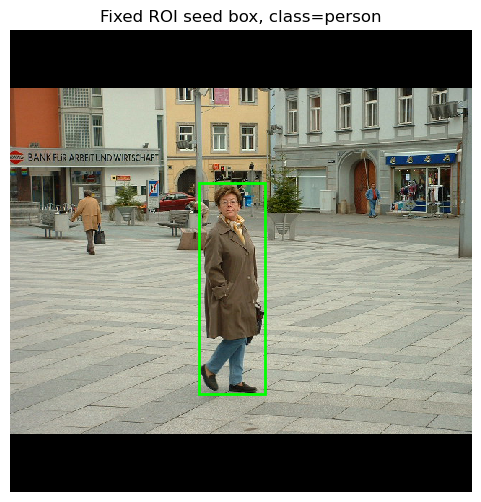


Top raw detector queries by class score:
 1. query=8248 class=  0 (person) score=+0.924187 box_xywh=[     307.49      357.74      90.533      291.66]
 2. query=8250 class=  0 (person) score=+0.918698 box_xywh=[     307.32      357.74      91.401      292.02]
 3. query=8249 class=  0 (person) score=+0.917791 box_xywh=[     307.16       357.5      91.275      292.52]
 4. query=8268 class=  0 (person) score=+0.914564 box_xywh=[     307.56      358.06      90.962       290.9]
 5. query=8269 class=  0 (person) score=+0.913852 box_xywh=[     307.25      357.64      91.239      291.47]
 6. query=8229 class=  0 (person) score=+0.912116 box_xywh=[     307.13      357.73      91.261      292.61]
 7. query=8270 class=  0 (person) score=+0.910616 box_xywh=[     307.45      357.72       91.11      291.32]
 8. query=8230 class=  0 (person) score=+0.907969 box_xywh=[     307.24      357.96      91.582      291.58]
 9. query=7046 class=  0 (person) score=+0.904957 box_xywh=[     104.46      266.19   

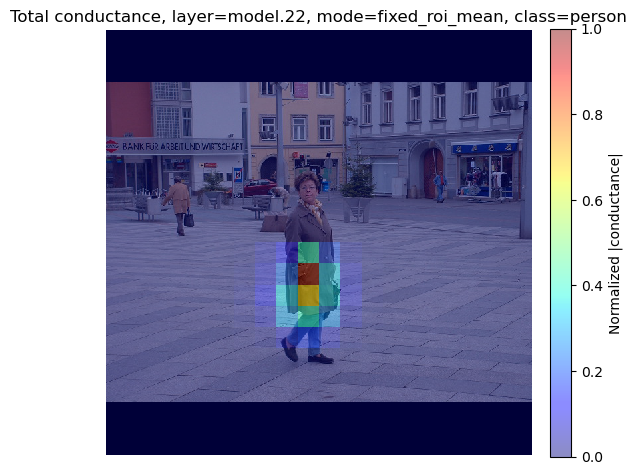

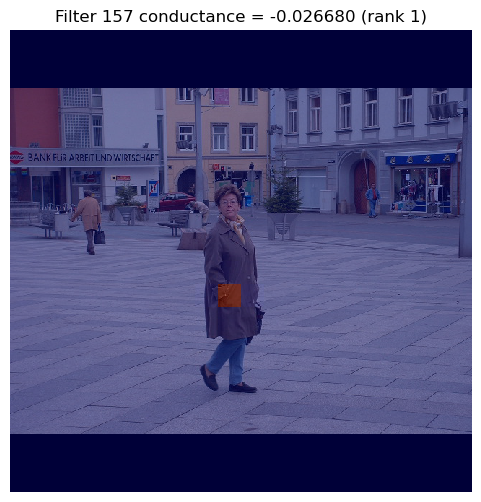

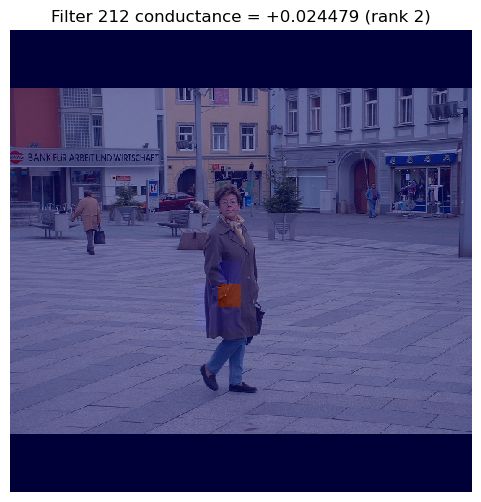

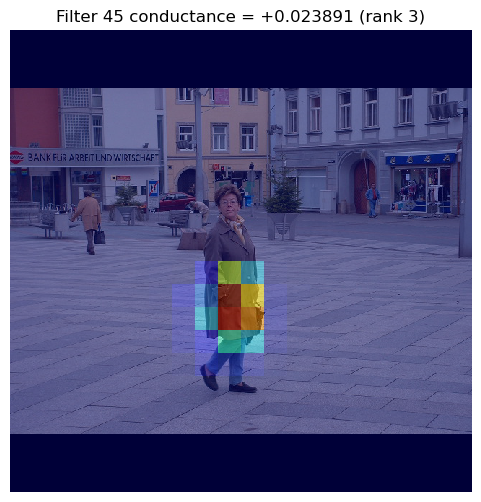

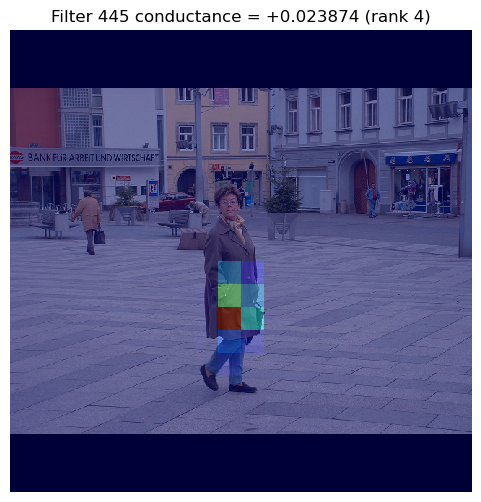

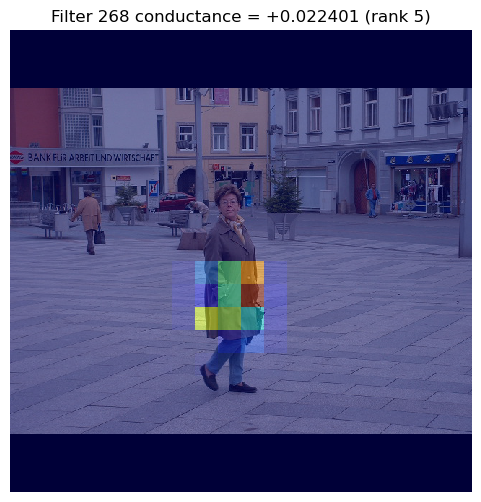

In [12]:
# %%
# Пример запуска: главный multi-scale pre-head слой перед Detect
result_prehead_all = run_detector_conductance(
    image_path="data/person.png",
    mode="fixed_roi_mean",
    layer_name="model.22",
    n_steps=128,
    top_n=5,
    roi_top_k=5,
)

# Дополнительные осмысленные варианты для сравнения:
# result_prehead_p3 = run_detector_conductance(
#     image_path="data/person.png",
#     mode="fixed_query",
#     layer_name="prehead_p3",
#     n_steps=64,
#     top_n=5,
# )
#
# result_prehead_p4 = run_detector_conductance(
#     image_path="data/person.png",
#     mode="fixed_query",
#     layer_name="prehead_p4",
#     n_steps=64,
#     top_n=5,
# )
#
# result_prehead_p5 = run_detector_conductance(
#     image_path="data/person.png",
#     mode="fixed_query",
#     layer_name="prehead_p5",
#     n_steps=64,
#     top_n=5,
# )

In [13]:
# %%
with torch.no_grad():
    raw_out = model(sample_x)

print("type(raw_out):", type(raw_out))

if isinstance(raw_out, (list, tuple)):
    print("len(raw_out):", len(raw_out))
    for i, item in enumerate(raw_out):
        print(f"\nraw_out[{i}] type:", type(item))
        if torch.is_tensor(item):
            print(f"raw_out[{i}] shape:", tuple(item.shape))
        elif isinstance(item, dict):
            print(f"raw_out[{i}] keys:", list(item.keys()))
            for k, v in item.items():
                if torch.is_tensor(v):
                    print(f"  {k}: {tuple(v.shape)}")
                elif isinstance(v, (list, tuple)):
                    tensor_shapes = [tuple(t.shape) for t in v if torch.is_tensor(t)]
                    print(f"  {k}: {tensor_shapes if tensor_shapes else type(v).__name__}")
                else:
                    print(f"  {k}: {type(v).__name__}")
        elif isinstance(item, (list, tuple)):
            tensor_shapes = [tuple(t.shape) for t in item if torch.is_tensor(t)]
            print(f"raw_out[{i}] tensor shapes:", tensor_shapes if tensor_shapes else type(item).__name__)

type(raw_out): <class 'tuple'>
len(raw_out): 2

raw_out[0] type: <class 'torch.Tensor'>
raw_out[0] shape: (1, 84, 8400)

raw_out[1] type: <class 'list'>
raw_out[1] tensor shapes: [(1, 144, 80, 80), (1, 144, 40, 40), (1, 144, 20, 20)]
